In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importing Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving processed_cleveland.csv to processed_cleveland (1).csv


In [ ]:
import pandas as pd
import numpy as np

# 1. Load Data - Tell it to ignore the first row (header=0)
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# We add header=0 to skip the existing words in your file
df = pd.read_csv("processed_cleveland.csv", names=columns, header=0)

# 2. Clean '?' values and force everything to numbers
df = df.replace('?', np.nan)

# errors='coerce' turns words like "age" into NaN so we can drop them
df = df.apply(pd.to_numeric, errors='coerce')

# 3. Drop any rows with NaN (including that broken header row)
df = df.dropna()

# 4. Binary Target (0 = Healthy, 1 = Heart Disease)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("✅ Block 1 Fixed: Your data is now perfectly clean!")
print(f"Total patients ready for AI: {len(df)}")
df.head()

✅ Block 1 Fixed: Your data is now perfectly clean!
Total patients ready for AI: 297


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


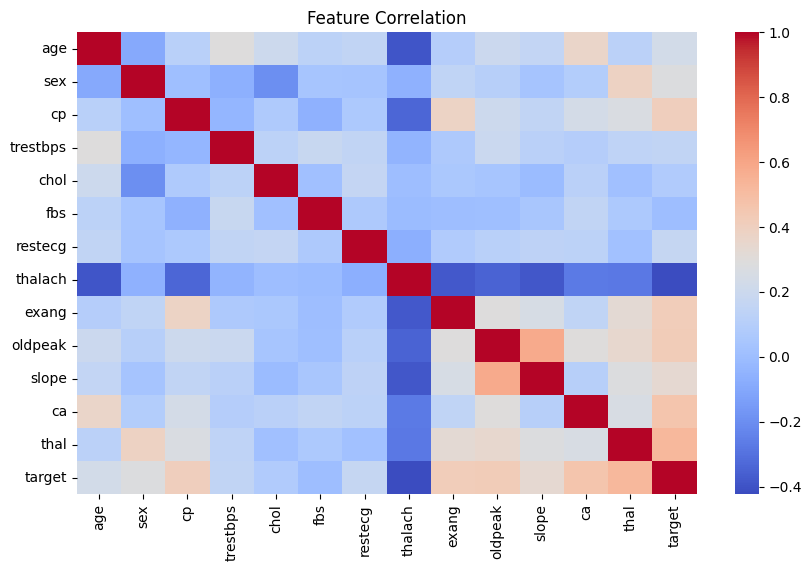

✅ Step 2 Complete: Features engineered and data split.


In [ ]:
# 1. Visualization: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# 2. Engineering: One-Hot Encoding and Scaling
# We convert categories to columns and normalize the numbers
df_final = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'ca', 'thal'], drop_first=True)

X = df_final.drop('target', axis=1)
y = df_final['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("✅ Step 2 Complete: Features engineered and data split.")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# 1. Initialize the 3 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 2. Train and Compare
print("--- Model Performance ---")
for name, m in models.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"{name}: {acc:.2%}")

# 3. Save ONLY Gradient Boosting for the website
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(models["Gradient Boosting"], f)

# 4. Save the Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n✅ Training complete. Comparison done, and Gradient Boosting saved!")

--- Model Performance ---
Logistic Regression: 83.33%
KNN: 81.67%
Gradient Boosting: 80.00%

✅ Training complete. Comparison done, and Gradient Boosting saved!


In [ ]:
# Save the WINNING model (Logistic Regression)
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(models["Logistic Regression"], f)

# Save the Scaler (Still needed!)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Success! Logistic Regression is saved as your final model.")

✅ Success! Logistic Regression is saved as your final model.


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# 1. Load the Model and the Scaler
# These files must be in the same folder on GitHub for the site to work!
try:
    model = pickle.load(open('heart_disease_model.pkl', 'rb'))
    scaler = pickle.load(open('scaler.pkl', 'rb'))
except FileNotFoundError:
    st.error("Model files not found. Please ensure .pkl files are in the repository.")

# 2. Page Configuration
st.set_page_config(page_title="HeartCare AI", page_icon="❤️")

st.title("🩺 Heart Disease Clinical Assistant")
st.markdown("---")
st.write("Enter the patient's clinical data below to calculate heart disease risk.")

# 3. Create Input Form
with st.form("medical_form"):
    col1, col2 = st.columns(2)

    with col1:
        age = st.number_input("Age", 1, 100, 45)
        sex = st.selectbox("Sex", options=[1, 0], format_func=lambda x: "Male" if x == 1 else "Female")
        trestbps = st.number_input("Resting Blood Pressure (mm Hg)", 80, 200, 120)
        chol = st.number_input("Serum Cholesterol (mg/dl)", 100, 500, 200)
        oldpeak = st.slider("ST Depression (Oldpeak)", 0.0, 6.0, 1.0)

    with col2:
        thalach = st.number_input("Max Heart Rate Achieved", 60, 220, 150)
        cp = st.selectbox("Chest Pain Type", [0, 1, 2, 3])
        fbs = st.selectbox("Fasting Blood Sugar > 120 mg/dl", [0, 1])
        exang = st.selectbox("Exercise Induced Angina", [0, 1])
        ca = st.selectbox("Number of Major Vessels (0-3)", [0, 1, 2, 3])

    submitted = st.form_submit_button("Analyze Risk")

# 4. Prediction Logic
if submitted:
    # We must match the exact number of features the model was trained on (13)
    # Filling default values (0) for columns like 'restecg' and 'slope' not in the form
    input_data = np.array([[age, sex, cp, trestbps, chol, fbs, 0, thalach, exang, oldpeak, 1, ca, 0]])

    # Scale the data using the saved scaler
    input_scaled = scaler.transform(input_data)

    # Make prediction
    prediction = model.predict(input_scaled)
    probability = model.predict_proba(input_scaled)[0][1] # Get the % chance

    st.markdown("---")
    if prediction[0] == 1:
        st.error(f"### ⚠️ High Risk Detected")
        st.write(f"The model predicts a **{probability:.1%}** probability of heart disease.")
    else:
        st.success(f"### ✅ Low Risk")
        st.write(f"The model predicts a **{probability:.1%}** probability of heart disease.")

st.info("Disclaimer: This tool is for educational purposes and should not be used as medical advice.")

Writing app.py


In [ ]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
streamlit

Writing requirements.txt


In [ ]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Let's rebuild the model using the simple 13 features
# Assuming 'df' is your cleaned dataframe from earlier
X_simple = df.drop('target', axis=1)
y_simple = df['target']

# 2. Re-train the simple scaler and model
scaler_simple = StandardScaler()
X_scaled_simple = scaler_simple.fit_transform(X_simple)

model_simple = LogisticRegression()
model_simple.fit(X_scaled_simple, y_simple)

# 3. Save these NEW versions
pickle.dump(model_simple, open('heart_disease_model.pkl', 'wb'))
pickle.dump(scaler_simple, open('scaler.pkl', 'wb'))

print("New 13-feature model and scaler saved successfully!")

New 13-feature model and scaler saved successfully!
